In [ ]:
pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: poorvatehlan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions


100%|██████████| 11.9M/11.9M [00:00<00:00, 14.1MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import signal
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

In [ ]:
data = pd.read_csv("/content/eeg-brainwave-dataset-feeling-emotions/emotions.csv")
data.head(3)

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.07,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.0,-162.0,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.55,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.6,-31.6,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.90,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.0,-148.0,281.00,POSITIVE


In [ ]:
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
data['label'] = data['label'].map(label_mapping)
print(data['label'].value_counts())

label
1    716
0    708
2    708
Name: count, dtype: int64


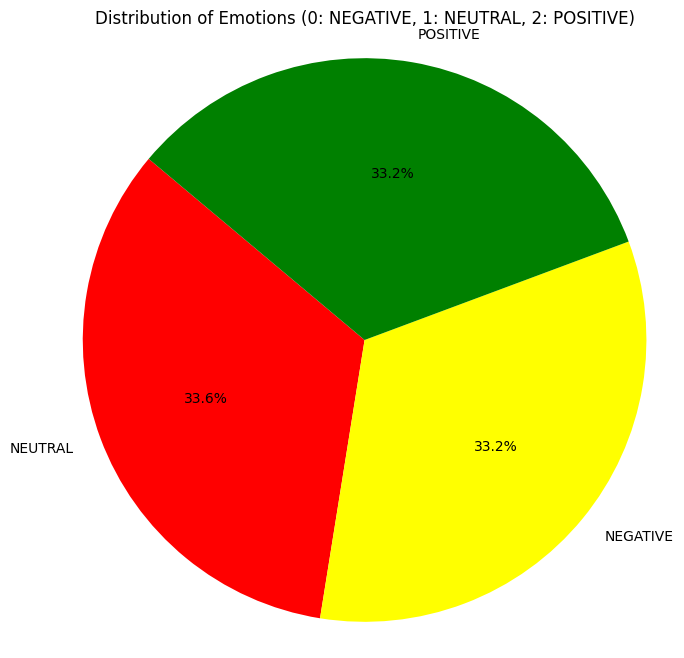

In [ ]:
emotion_counts = data['label'].value_counts()
emotional_labels = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
emotion_labels = [emotional_labels[label] for label in emotion_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_labels, autopct='%1.1f%%',
        startangle=140, colors=['red', 'yellow', 'green'])
plt.title("Distribution of Emotions (0: NEGATIVE, 1: NEUTRAL, 2: POSITIVE)")
plt.axis('equal')
plt.show()

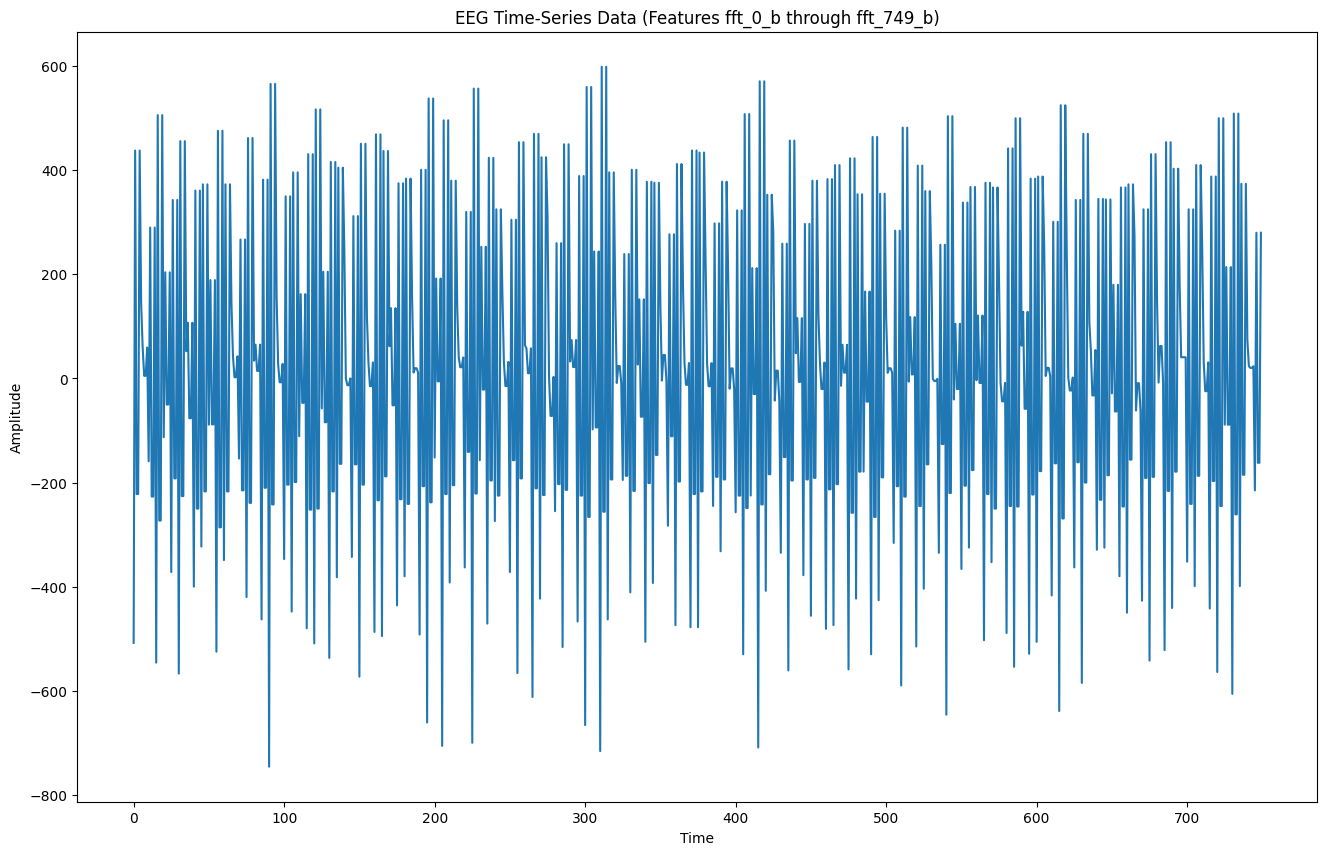

In [ ]:
sample = data.loc[0, 'fft_0_b':'fft_749_b']
plt.figure(figsize=(16, 10))
plt.plot(range(len(sample)), sample)
plt.title("EEG Time-Series Data (Features fft_0_b through fft_749_b)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

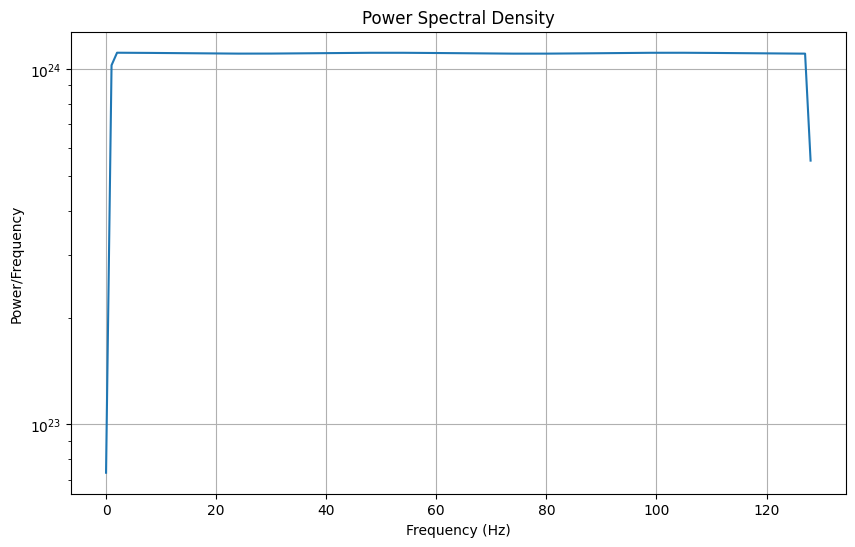

In [ ]:
features = data.drop('label', axis=1)
sample_array = features.iloc[0].to_numpy()
sampling_rate = 256

frequencies, power_density = signal.welch(sample_array, fs=sampling_rate)
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies, power_density)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency")
plt.grid()
plt.show()

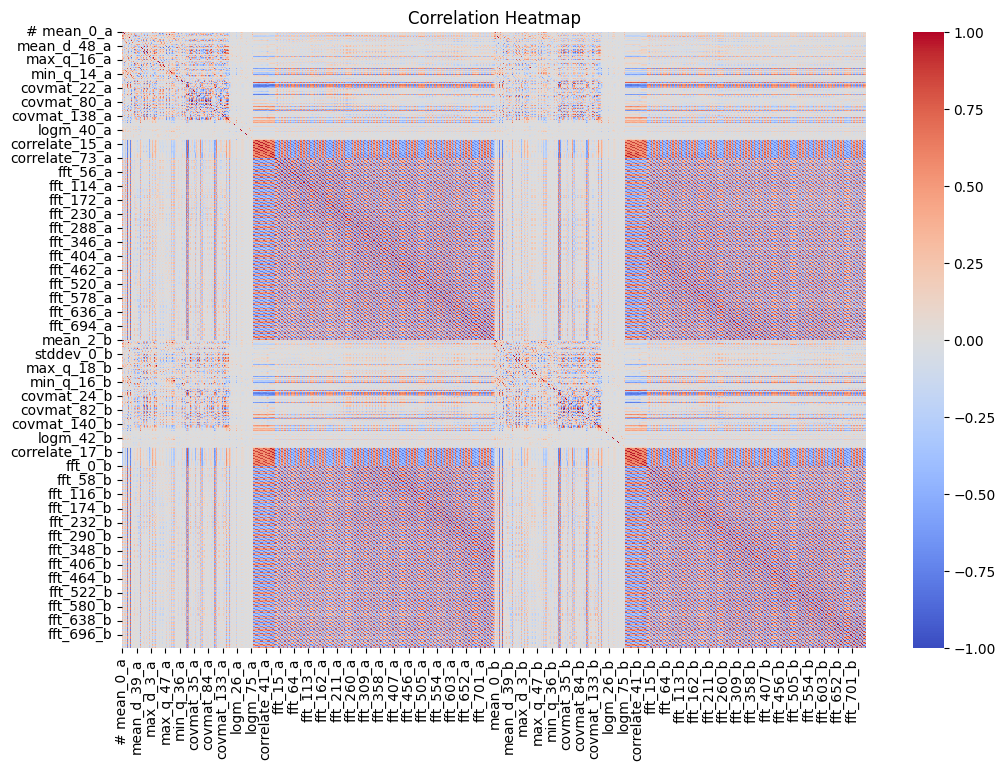

In [ ]:
correlation_matrix = data.drop('label', axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

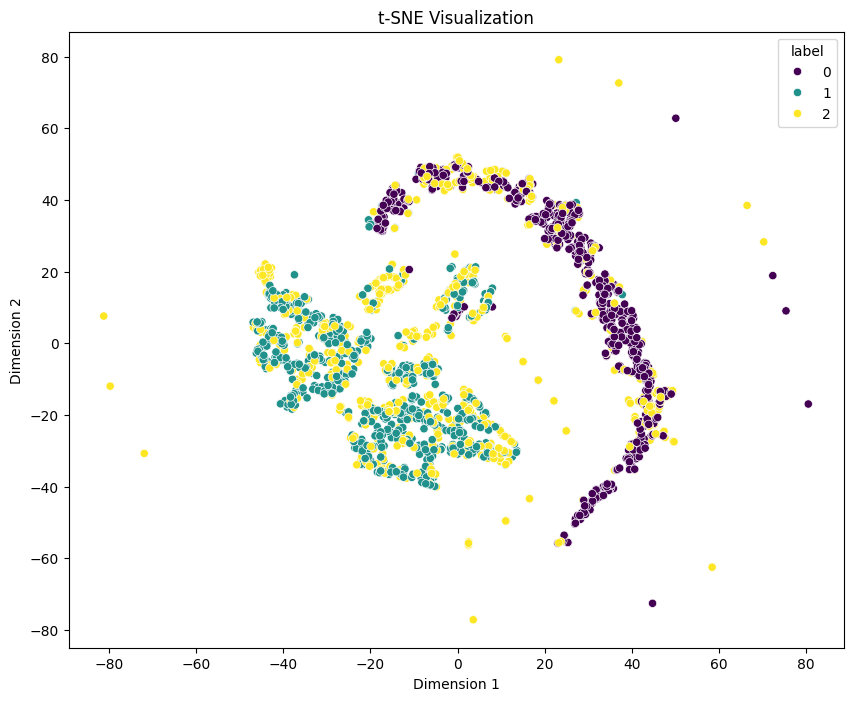

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(data.drop('label', axis=1))
tsne_df = pd.DataFrame(tsne_results, columns=['Dimension 1', 'Dimension 2'])
tsne_df['label'] = data['label'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dimension 1', y='Dimension 2', hue='label',
                data=tsne_df, palette='viridis')
plt.title("t-SNE Visualization")
plt.show()

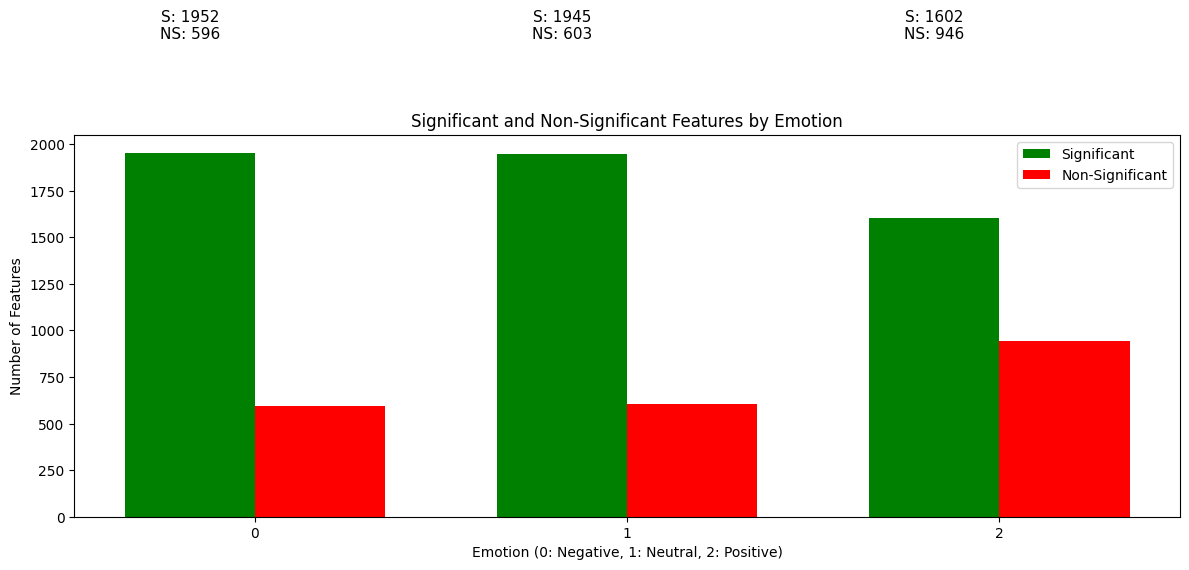

In [ ]:
emotions = data['label'].unique()
num_features = {emotion: {'significant': 0, 'non-significant': 0} for emotion in emotions}

for emotion in emotions:
    subset = data[data['label'] == emotion]
    for feature in data.columns[:-1]:
        _, p_value = ttest_ind(subset[feature], data[feature])
        if p_value < 0.05:
            num_features[emotion]['significant'] += 1
        else:
            num_features[emotion]['non-significant'] += 1

emotion_labels_list = list(num_features.keys())
significant_counts = [num_features[e]['significant'] for e in emotion_labels_list]
non_significant_counts = [num_features[e]['non-significant'] for e in emotion_labels_list]

bar_width = 0.35
index = np.arange(len(emotion_labels_list))

plt.figure(figsize=(12, 6))
plt.bar(index, significant_counts, bar_width, label='Significant', color='green')
plt.bar(index + bar_width, non_significant_counts, bar_width, label='Non-Significant', color='red')
plt.xlabel('Emotion (0: Negative, 1: Neutral, 2: Positive)')
plt.ylabel('Number of Features')
plt.title('Significant and Non-Significant Features by Emotion')
plt.xticks(index + bar_width / 2, emotion_labels_list)
plt.legend()

for i, (s, ns) in enumerate(zip(significant_counts, non_significant_counts)):
    plt.text(i, s + ns + 1, f'S: {s}\nNS: {ns}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
data.iloc[:, :-1] = scaler.fit_transform(data.iloc[:, :-1])

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (1492, 2548), Test size: (640, 2548)


In [ ]:
fnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

fnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print(fnn_model.summary())

fnn_history = fnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=70,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       652,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,827 (2.62 MB)

 Trainable params: 685,827 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/70
38/38 - 5s - 142ms/step - accuracy: 0.7494 - loss: 1.1911 - val_accuracy: 0.9030 - val_loss: 0.6927
Epoch 2/70
38/38 - 0s - 5ms/step - accuracy: 0.8500 - loss: 0.7969 - val_accuracy: 0.9030 - val_loss: 0.7661
Epoch 3/70
38/38 - 0s - 5ms/step - accuracy: 0.8801 - loss: 0.5517 - val_accuracy: 0.9264 - val_loss: 0.2933
Epoch 4/70
38/38 - 0s - 5ms/step - accuracy: 0.8961 - loss: 0.4136 - val_accuracy: 0.9097 - val_loss: 0.3620
Epoch 5/70
38/38 - 0s - 5ms/step - accuracy: 0.9086 - loss: 0.3748 - val_accuracy: 0.9097 - val_loss: 0.3398
Epoch 6/70
38/38 - 0s - 5ms/step - accuracy: 0.9103 - loss: 0.3469 - val_accuracy: 0.9264 - val_loss: 0.3743
Epoch 7/70
38/38 - 0s - 5ms/step - accuracy: 0.9271 - loss: 0.2780 - val_accuracy: 0.9298 - val_loss: 0.2757
Epoch 8/70
38/38 - 1s - 18ms/step - accuracy: 0.9279 - loss: 0.2356 - val_accuracy: 0.9398 - val_loss: 0.2510
Epoch 9/70
38/38 - 0s - 7ms/step - accuracy: 0.9422 - loss: 0.1642 - val_accuracy: 0.9164 - val_loss: 0.2891
Epoch 10/70

In [ ]:
rnn_inputs = tf.keras.Input(shape=(X_train.shape[1],))
expand_dims = tf.keras.layers.Reshape((X_train.shape[1], 1))(rnn_inputs)  # use Keras layer instead
rnn_layer = tf.keras.layers.SimpleRNN(256, return_sequences=True)(expand_dims)
flatten = tf.keras.layers.Flatten()(rnn_layer)
rnn_outputs = tf.keras.layers.Dense(3, activation='softmax')(flatten)

rnn_model = tf.keras.Model(inputs=rnn_inputs, outputs=rnn_outputs)

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print(rnn_model.summary())

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=2
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2548)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2548, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 2548, 256)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 652288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │     1,956,867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,022,915 (7.72 MB)

 Trainable params: 2,022,915 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
38/38 - 13s - 350ms/step - accuracy: 0.7477 - loss: 4.3215 - val_accuracy: 0.6823 - val_loss: 2.4538
Epoch 2/50
38/38 - 6s - 167ms/step - accuracy: 0.4887 - loss: 17.5927 - val_accuracy: 0.2609 - val_loss: 36.9026
Epoch 3/50
38/38 - 6s - 171ms/step - accuracy: 0.4040 - loss: 108.2430 - val_accuracy: 0.3880 - val_loss: 68.1807
Epoch 4/50
38/38 - 6s - 167ms/step - accuracy: 0.5172 - loss: 117.5649 - val_accuracy: 0.6355 - val_loss: 72.8703
Epoch 5/50
38/38 - 6s - 170ms/step - accuracy: 0.6027 - loss: 89.8120 - val_accuracy: 0.6355 - val_loss: 86.1122
Epoch 6/50
38/38 - 6s - 167ms/step - accuracy: 0.6798 - loss: 46.9655 - val_accuracy: 0.6823 - val_loss: 20.2333
Epoch 7/50
38/38 - 6s - 170ms/step - accuracy: 0.6672 - loss: 31.6005 - val_accuracy: 0.7090 - val_loss: 24.7413
Epoch 8/50
38/38 - 6s - 168ms/step - accuracy: 0.7351 - loss: 28.2326 - val_accuracy: 0.6555 - val_loss: 65.1917
Epoch 9/50
38/38 - 6s - 171ms/step - accuracy: 0.7485 - loss: 28.5794 - val_accuracy: 0.78

In [ ]:
fnn_acc = fnn_model.evaluate(X_test, y_test, verbose=0)[1]
rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)[1]

print(f"FNN Test Accuracy:        {fnn_acc * 100:.3f}%")
print(f"RNN Test Accuracy: {rnn_acc * 100:.3f}%")

FNN Test Accuracy:        93.594%
RNN Test Accuracy: 88.437%


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


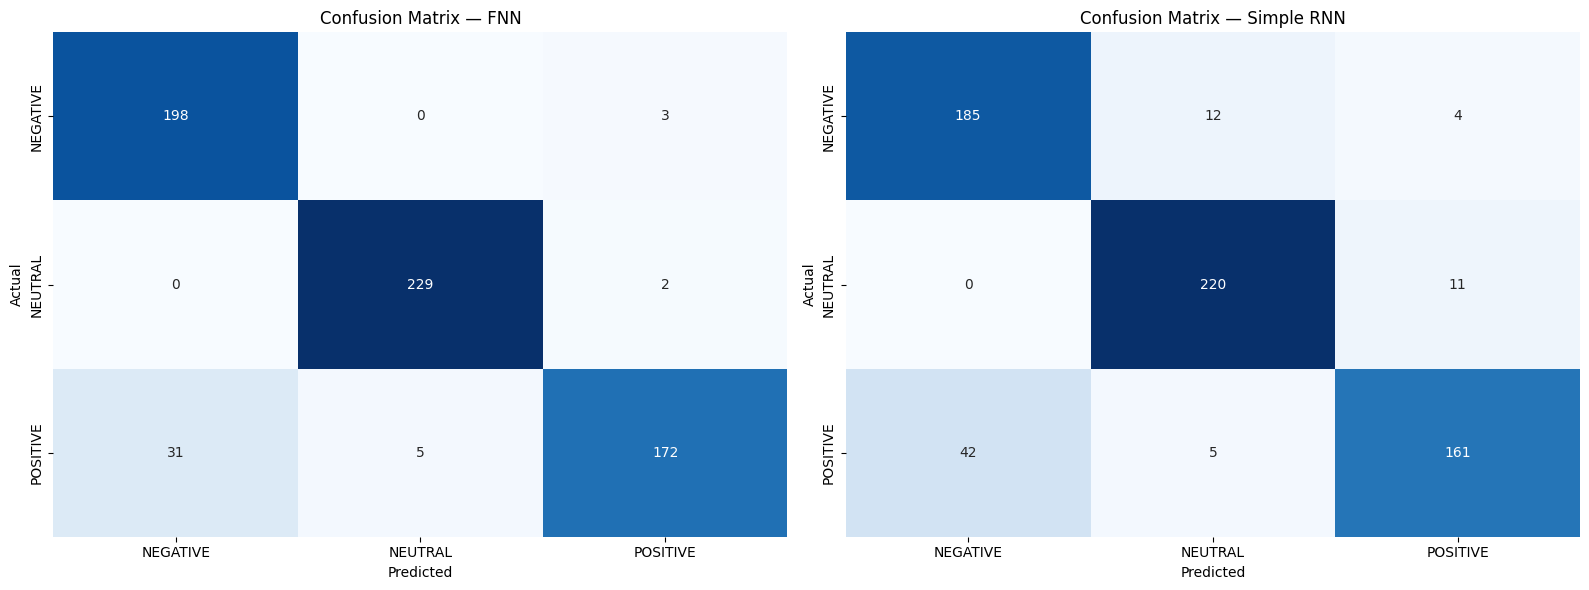

In [ ]:
y_pred_fnn = np.argmax(fnn_model.predict(X_test), axis=1)
y_pred_rnn = np.argmax(rnn_model.predict(X_test), axis=1)

cm_fnn = confusion_matrix(y_test, y_pred_fnn)
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names = list(label_mapping.keys())

for ax, cm, title in zip(axes, [cm_fnn, cm_rnn], ['FNN', 'Simple RNN']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.show()

In [ ]:
clr_fnn = classification_report(y_test, y_pred_fnn, target_names=label_mapping.keys())
clr_rnn = classification_report(y_test, y_pred_rnn, target_names=label_mapping.keys())

print("=" * 50)
print("FNN Classification Report:")
print("=" * 50)
print(clr_fnn)

print("=" * 50)
print("Simple RNN Classification Report:")
print("=" * 50)
print(clr_rnn)

FNN Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.86      0.99      0.92       201
     NEUTRAL       0.98      0.99      0.98       231
    POSITIVE       0.97      0.83      0.89       208

    accuracy                           0.94       640
   macro avg       0.94      0.93      0.93       640
weighted avg       0.94      0.94      0.94       640

Simple RNN Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.81      0.92      0.86       201
     NEUTRAL       0.93      0.95      0.94       231
    POSITIVE       0.91      0.77      0.84       208

    accuracy                           0.88       640
   macro avg       0.89      0.88      0.88       640
weighted avg       0.89      0.88      0.88       640



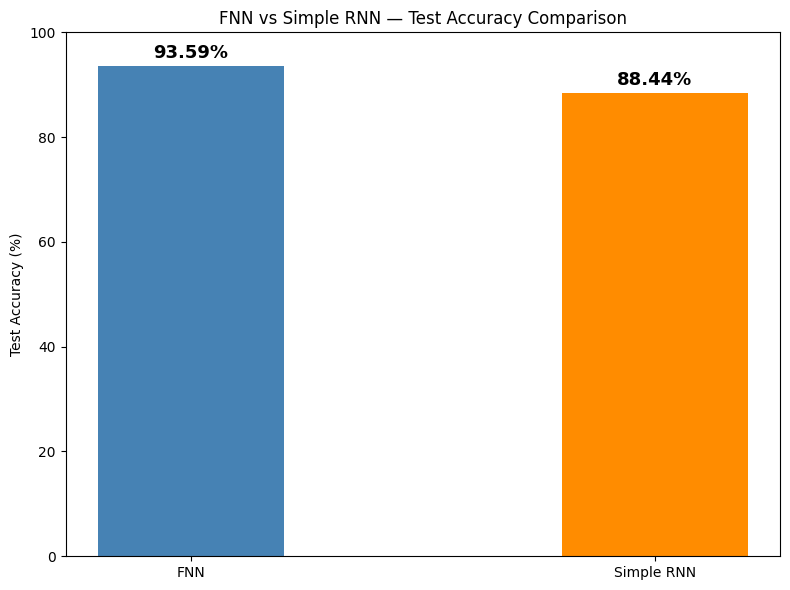


 Better model: FNN with 93.594% accuracy


In [ ]:
models = ['FNN', 'Simple RNN']
accuracies = [fnn_acc * 100, rnn_acc * 100]
colors = ['steelblue', 'darkorange']

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.4)
plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('FNN vs Simple RNN — Test Accuracy Comparison')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.8,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

winner = models[np.argmax(accuracies)]
print(f"\n Better model: {winner} with {max(accuracies):.3f}% accuracy")